In [1]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('Dataset/HR-Employee-Attrition.csv')
df_num = df.copy()
df_num['Attrition'] = df_num['Attrition'].map({'Yes':1,'No':0})


In [2]:
df_num.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
le = LabelEncoder()
for col in df_num.select_dtypes(include='object').columns:
    df_num[col] = le.fit_transform(df_num[col].astype(str))

C:\Users\thinh_we1vuu3\AppData\Local\Temp\ipykernel_18988\643278267.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_num.select_dtypes(include='object').columns:


In [5]:
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   int64
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

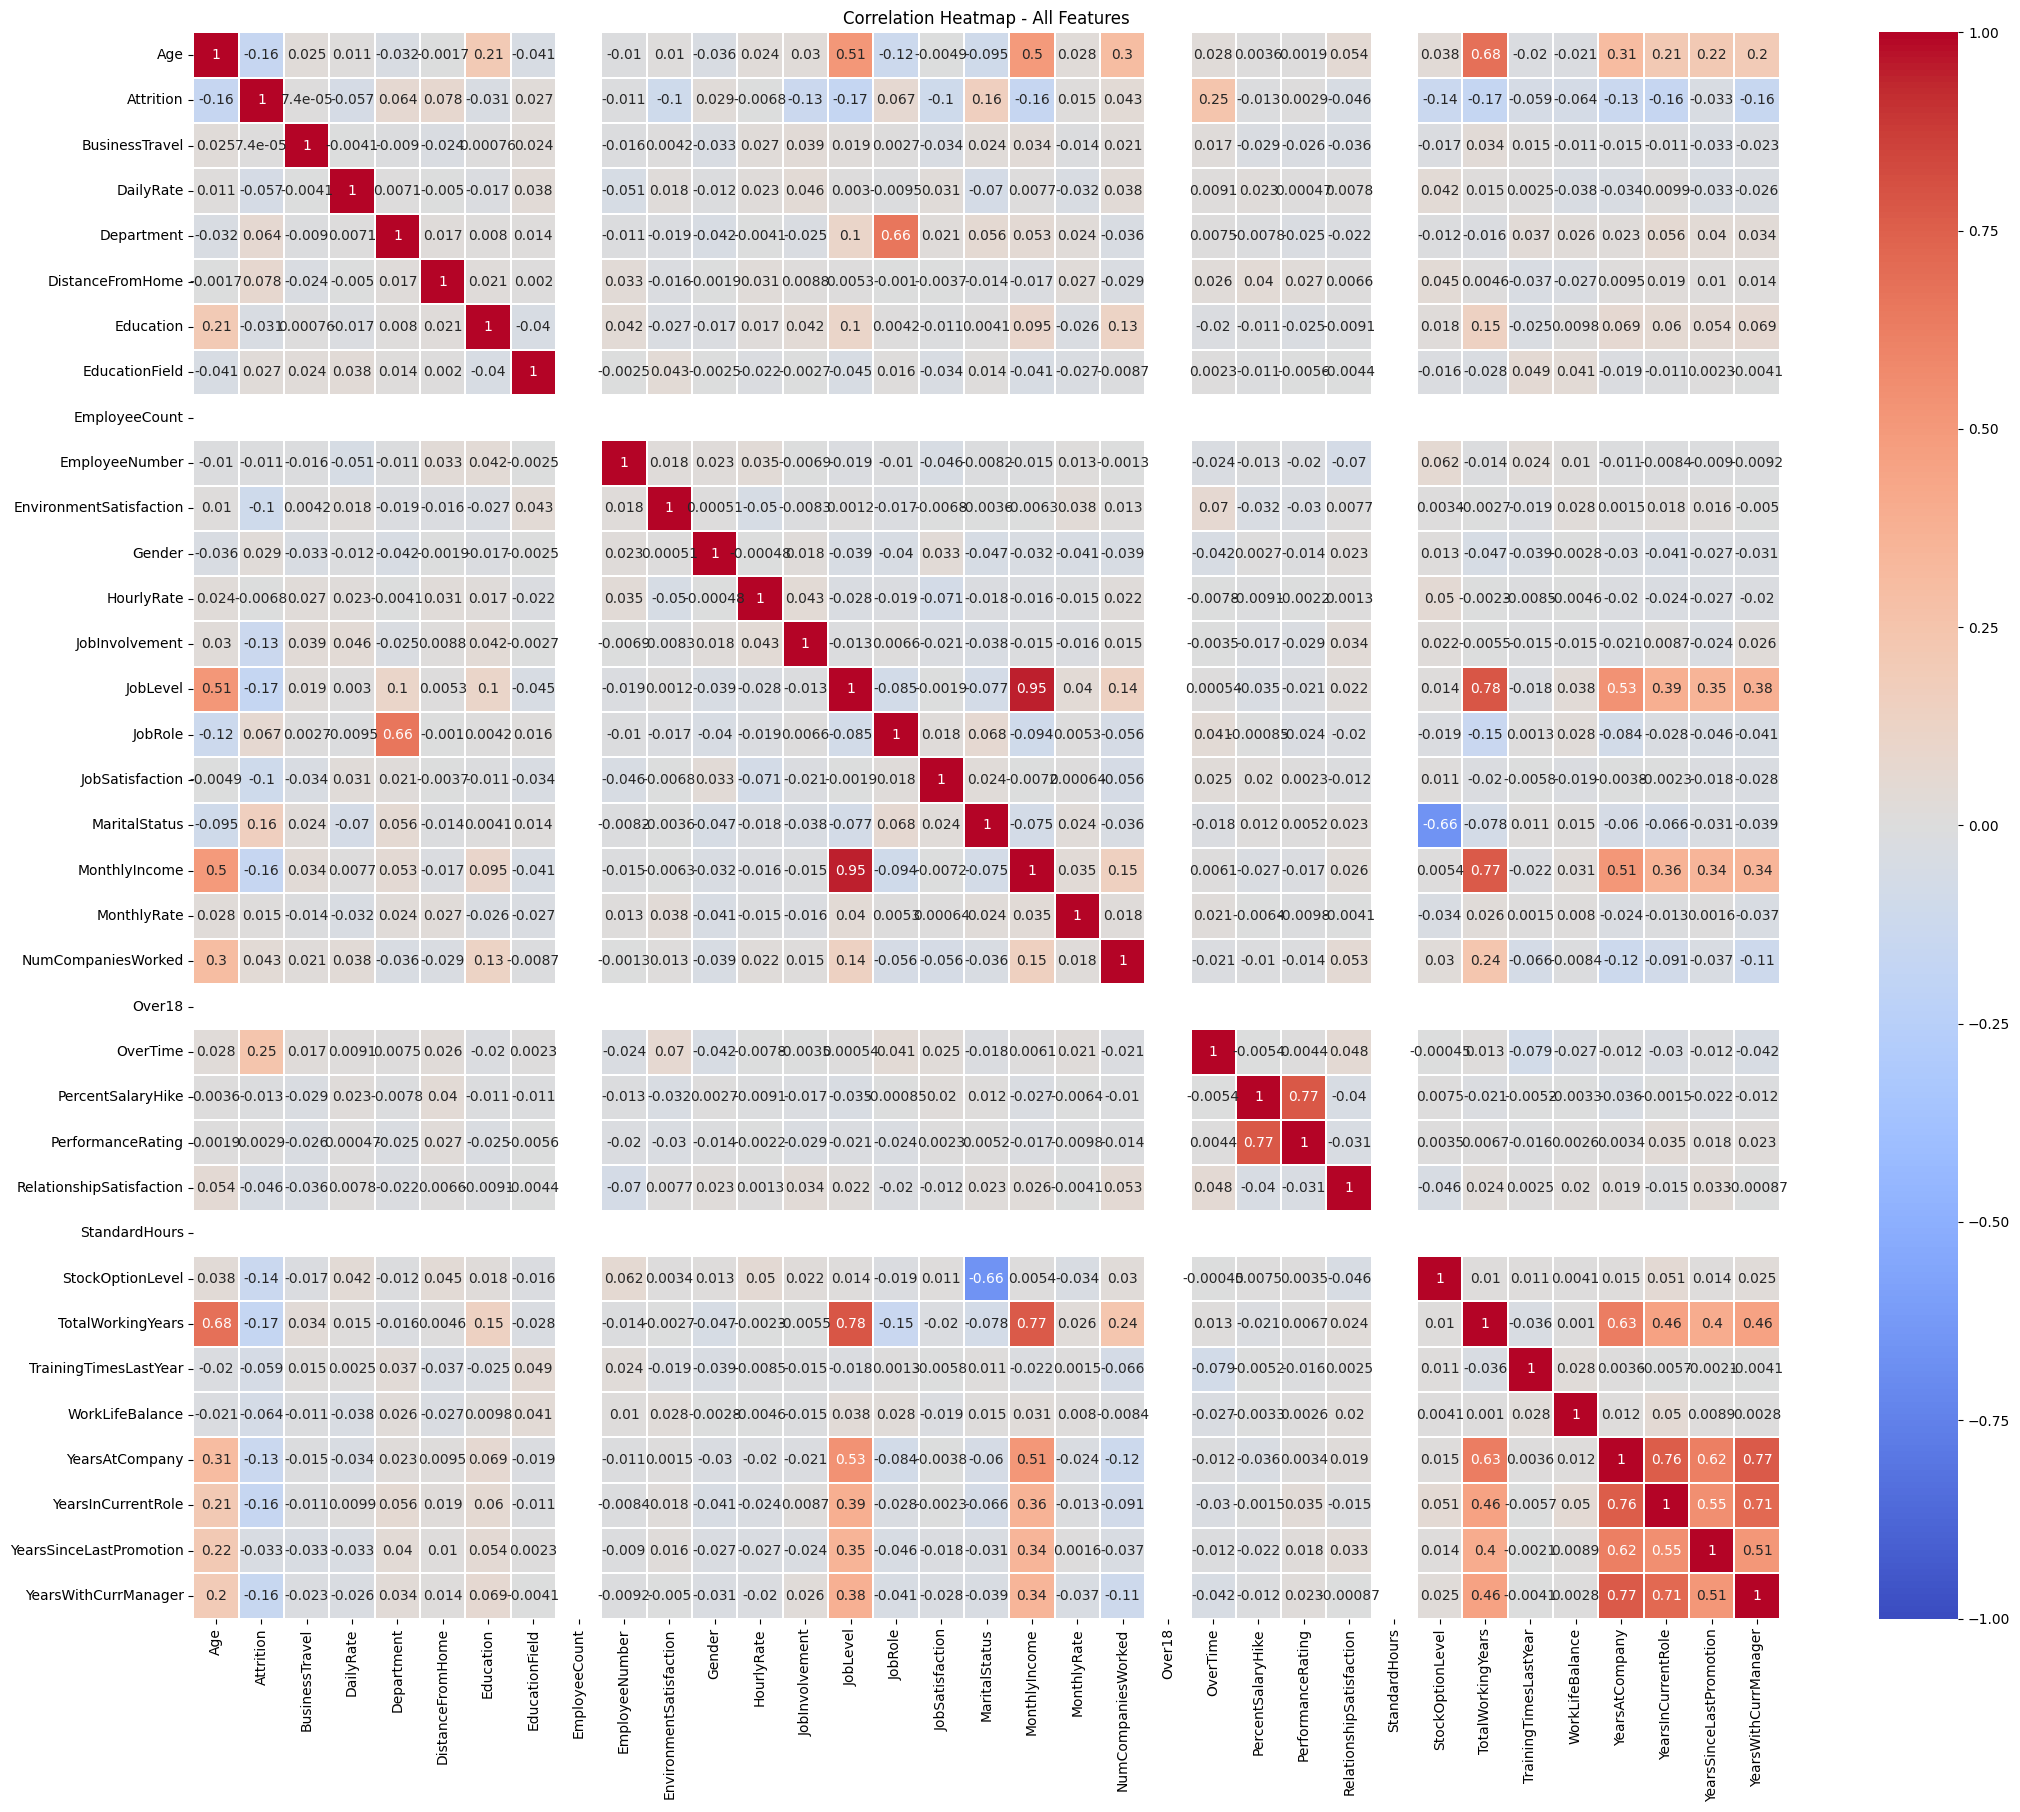

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_num.corr(numeric_only=True)
plt.figure(figsize=(22, 18))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot=True
)
plt.title('Correlation Heatmap - All Features')
plt.tight_layout()
plt.show()

In [7]:
corr = df_num.corr(numeric_only=True)['Attrition'].drop('Attrition').dropna().sort_values(ascending=False)

print('Top 5 correlation duong:')
print(corr.head(5))
print('\nTop 5 correlation am:')
print(corr.tail(5))

Top 5 correlation duong:
OverTime            0.246118
MaritalStatus       0.162070
DistanceFromHome    0.077924
JobRole             0.067151
Department          0.063991
Name: Attrition, dtype: float64

Top 5 correlation am:
Age                  -0.159205
MonthlyIncome        -0.159840
YearsInCurrentRole   -0.160545
JobLevel             -0.169105
TotalWorkingYears    -0.171063
Name: Attrition, dtype: float64


In [8]:
features = [
    'OverTime',
    'MaritalStatus',
    'TotalWorkingYears',
    'JobLevel',
    'YearsInCurrentRole'
]
X = pd.get_dummies(df[features], drop_first=True)
y = df['Attrition'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
y_pred = logreg.predict(X_test_s)

print("Features:", features)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(pd.Series(logreg.coef_[0], index=X.columns).sort_values())

Features: ['OverTime', 'MaritalStatus', 'TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole']
Accuracy: 0.864
TotalWorkingYears       -0.408250
YearsInCurrentRole      -0.308461
JobLevel                -0.172292
MaritalStatus_Married    0.084325
MaritalStatus_Single     0.484406
OverTime_Yes             0.604615
dtype: float64


In [9]:
# Lay 1 nhan vien trong tap test lam mau
employee = X_test.iloc[[0]].copy()

# Cau hoi 1: Neu nhan vien khong tang ca?
case_1 = employee.copy()
case_1['OverTime_Yes'] = 0
case_1_scaled = scaler.transform(case_1)
prob_1 = logreg.predict_proba(case_1_scaled)[0][1] * 100
group_1 = logreg.predict(case_1_scaled)[0]
print('Khong tang ca:', round(prob_1, 1), '% -', 'Nghi viec' if group_1 == 1 else 'Khong nghi viec')

# Cau hoi 2: Neu nhan vien tang ca?
case_2 = employee.copy()
case_2['OverTime_Yes'] = 1
case_2_scaled = scaler.transform(case_2)
prob_2 = logreg.predict_proba(case_2_scaled)[0][1] * 100
group_2 = logreg.predict(case_2_scaled)[0]
print('Tang ca:', round(prob_2, 1), '% -', 'Nghi viec' if group_2 == 1 else 'Khong nghi viec')

# Cau hoi 3: Neu nhan vien co 15 nam kinh nghiem?
case_3 = employee.copy()
case_3['TotalWorkingYears'] = 15
case_3_scaled = scaler.transform(case_3)
prob_3 = logreg.predict_proba(case_3_scaled)[0][1] * 100
group_3 = logreg.predict(case_3_scaled)[0]
print('Kinh nghiem 15 nam:', round(prob_3, 1), '% -', 'Nghi viec' if group_3 == 1 else 'Khong nghi viec')

# Cau hoi 4: Neu job level la 4?
case_4 = employee.copy()
case_4['JobLevel'] = 4
case_4_scaled = scaler.transform(case_4)
prob_4 = logreg.predict_proba(case_4_scaled)[0][1] * 100
group_4 = logreg.predict(case_4_scaled)[0]
print('Job level = 4:', round(prob_4, 1), '% -', 'Nghi viec' if group_4 == 1 else 'Khong nghi viec')

# Cau hoi 5: Neu nhan vien doc than?
case_5 = employee.copy()
case_5['MaritalStatus_Married'] = 0
case_5['MaritalStatus_Single'] = 1
case_5_scaled = scaler.transform(case_5)
prob_5 = logreg.predict_proba(case_5_scaled)[0][1] * 100
group_5 = logreg.predict(case_5_scaled)[0]
print('Doc than:', round(prob_5, 1), '% -', 'Nghi viec' if group_5 == 1 else 'Khong nghi viec')

Khong tang ca: 17.8 % - Khong nghi viec
Tang ca: 45.2 % - Khong nghi viec
Kinh nghiem 15 nam: 9.4 % - Khong nghi viec
Job level = 4: 11.9 % - Khong nghi viec
Doc than: 34.2 % - Khong nghi viec


In [14]:
# Lấy 1 nhân viên trong tập test làm mẫu
employee = X_test.iloc[[0]].copy()

# HÀM DÙNG CHUNG: truyền vào các thay đổi muốn thử, hàm tự tính xác suất
def what_if(base_row, changes: dict, label: str):
    row = base_row.copy()
    for col, value in changes.items():
        row[col] = value
    
    row_scaled = scaler.transform(row)
    prob = logreg.predict_proba(row_scaled)[0][1] * 100
    ket_qua = 'Nghỉ việc' if prob >= 50 else 'Không nghỉ việc'
    
    print(f"{label:<25}: {round(prob, 1)}%  →  {ket_qua}")
    return prob

In [15]:
print("=== KỊCH BẢN 1: Làm thêm giờ (OverTime) ===")
what_if(employee, {'OverTime_Yes': 0}, 'Không tăng ca')
what_if(employee, {'OverTime_Yes': 1}, 'Có tăng ca')

print("\n=== KỊCH BẢN 2: Kinh nghiệm làm việc ===")
what_if(employee, {'TotalWorkingYears': 2}, 'Kinh nghiệm 2 năm')
what_if(employee, {'TotalWorkingYears': 15}, 'Kinh nghiệm 15 năm')

print("\n=== KỊCH BẢN 3: Cấp bậc công việc (Job Level) ===")
what_if(employee, {'JobLevel': 1}, 'Job Level = 1')
what_if(employee, {'JobLevel': 4}, 'Job Level = 4')

print("\n=== KỊCH BẢN 4: Tình trạng hôn nhân ===")
what_if(employee, {'MaritalStatus_Married': 1, 'MaritalStatus_Single': 0}, 'Đã kết hôn')
what_if(employee, {'MaritalStatus_Married': 0, 'MaritalStatus_Single': 1}, 'Độc thân')

print("\n=== KỊCH BẢN 5: Kết hợp nhiều yếu tố cùng lúc ===")
what_if(employee, {'OverTime_Yes': 1, 'JobLevel': 1, 'TotalWorkingYears': 1}, 'OT + Level thấp + Ít KN')
what_if(employee, {'OverTime_Yes': 0, 'JobLevel': 4, 'TotalWorkingYears': 15}, 'Không OT + Level cao + Nhiều KN')

=== KỊCH BẢN 1: Làm thêm giờ (OverTime) ===
Không tăng ca            : 17.8%  →  Không nghỉ việc
Có tăng ca               : 45.2%  →  Không nghỉ việc

=== KỊCH BẢN 2: Kinh nghiệm làm việc ===
Kinh nghiệm 2 năm        : 17.1%  →  Không nghỉ việc
Kinh nghiệm 15 năm       : 9.4%  →  Không nghỉ việc

=== KỊCH BẢN 3: Cấp bậc công việc (Job Level) ===
Job Level = 1            : 17.8%  →  Không nghỉ việc
Job Level = 4            : 11.9%  →  Không nghỉ việc

=== KỊCH BẢN 4: Tình trạng hôn nhân ===
Đã kết hôn               : 17.8%  →  Không nghỉ việc
Độc thân                 : 34.2%  →  Không nghỉ việc

=== KỊCH BẢN 5: Kết hợp nhiều yếu tố cùng lúc ===
OT + Level thấp + Ít KN  : 45.2%  →  Không nghỉ việc
Không OT + Level cao + Nhiều KN: 6.1%  →  Không nghỉ việc


np.float64(6.101355310616291)

In [19]:
# Lấy 1 nhân viên mẫu từ tập Test
employee = X_test.iloc[[0]].copy()

In [17]:
employee['OverTime_Yes'] = 0
prob = logreg.predict_proba(scaler.transform(employee))[0][1] * 100
print('Không tăng ca:', round(prob, 1), '%')

employee['OverTime_Yes'] = 1
prob = logreg.predict_proba(scaler.transform(employee))[0][1] * 100
print('Có tăng ca   :', round(prob, 1), '%')

Không tăng ca: 17.8 %
Có tăng ca   : 45.2 %


In [ ]:
employee['OverTime_Yes'] = 0
prob = logreg.predict_proba(scaler.transform(employee))[0][1] * 100
print('Không tăng ca:', round(prob, 1), '%')

employee['OverTime_Yes'] = 1
prob = logreg.predict_proba(scaler.transform(employee))[0][1] * 100
print('Có tăng ca   :', round(prob, 1), '%')

In [24]:
employee = X_test.iloc[[0]].copy()

# # Cau hoi 1: Neu nhan vien khong tang ca?
# case_1 = employee.copy()
# case_1['OverTime_Yes'] = 0
# case_1_scaled = scaler.transform(case_1)
# prob_1 = logreg.predict_proba(case_1_scaled)[0][1] * 100
# group_1 = logreg.predict(case_1_scaled)[0]

In [25]:
case_1 = employee.copy()
case_1

,TotalWorkingYears,JobLevel,YearsInCurrentRole,OverTime_Yes,MaritalStatus_Married,MaritalStatus_Single
1061,1,1,0,False,True,False


In [26]:
case_1['OverTime_Yes'] = 0
case_1

,TotalWorkingYears,JobLevel,YearsInCurrentRole,OverTime_Yes,MaritalStatus_Married,MaritalStatus_Single
1061,1,1,0,0,True,False


In [27]:
case_1_scaled = scaler.transform(case_1)
case_1_scaled

array([[-1.32914826, -0.98626491, -1.18590534, -0.63772923,  1.08525471,
        -0.68154831]])

In [ ]:
prob_1 = logreg.predict_proba(case_1_scaled)[0][1] * 100

In [29]:
prob_1

np.float64(17.839935120497355)

In [30]:
# 1. Lấy mảng xác suất của nhân viên đầu tiên
probs = logreg.predict_proba(case_1_scaled)[0]

# 2. Lấy xác suất nghỉ việc (Class 1)
prob_stay = probs[0]     # Xác suất Ở LẠI (Class 0)
prob_leave = probs[1]    # Xác suất NGHỈ VIỆC (Class 1)

# 3. Đổi sang %
prob_1 = prob_leave * 100

In [31]:
print(prob_stay)
print(prob_leave)

0.8216006487950265
0.17839935120497355


In [32]:
probs

array([0.82160065, 0.17839935])